## Project Name : Customer Segementation using Machine Learning

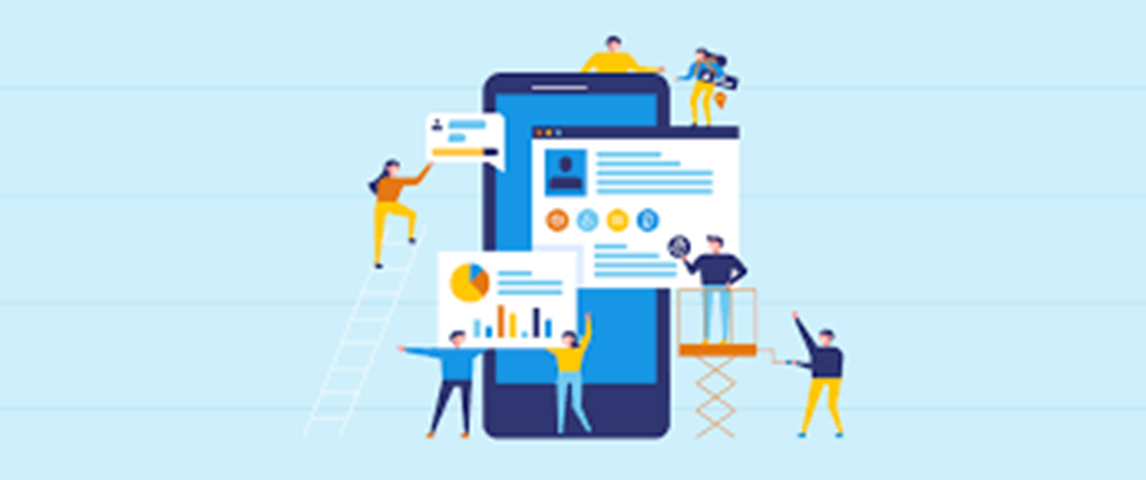

## Objective
The goal of this project is to perform customer segmentation using machine learning techniques to group customers based on their characteristics.

In marketing, market segmentation is the process of dividing a broad consumer or business market, normally consisting of existing and potential customers, into sub-groups of consumers based on some type of shared characteristics.

We will be using Machine Learning to perform Customer Segmentation 

#### Time Line of the project:
- Importing Libraries
- Data Analysis
- Data Preprocessing'
- Model Building

#### Importing Libraries

In [52]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

In [54]:
df = pd.read_csv('Train.csv')
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


### Data Analysis

__Checking for Datatypes__

In [55]:
#info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [56]:
df['Segmentation'].value_counts()

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64

In [57]:
#describe
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


**Checking for column names**

In [58]:
col= df.columns
col

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

#### Checking null values

In [59]:
df.shape

(8068, 11)

In [60]:
df.isnull().sum()

ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [61]:
df.ffill(inplace=True)

In [62]:
df.isnull().sum()

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

#### Data Analysis

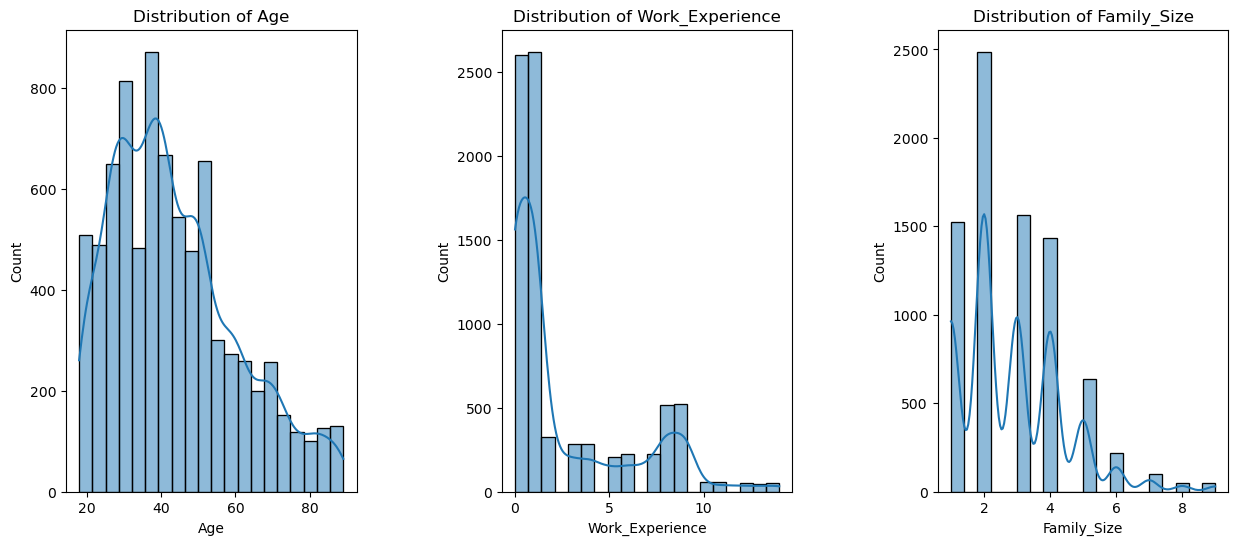

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(1, figsize=(15, 6))
n = 0

for x in ['Age', 'Work_Experience', 'Family_Size']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.histplot(df[x], bins=20, kde=True)
    plt.title(f'Distribution of {x}')

plt.show()

In [64]:
df.groupby('Segmentation')[['Age','Work_Experience','Family_Size']].agg('mean')

,Age,Work_Experience,Family_Size
Segmentation,,,
A,44.924949,2.806795,2.446755
B,48.200215,2.391819,2.696448
C,49.144162,2.247716,2.971574
D,33.390212,2.963404,3.208995


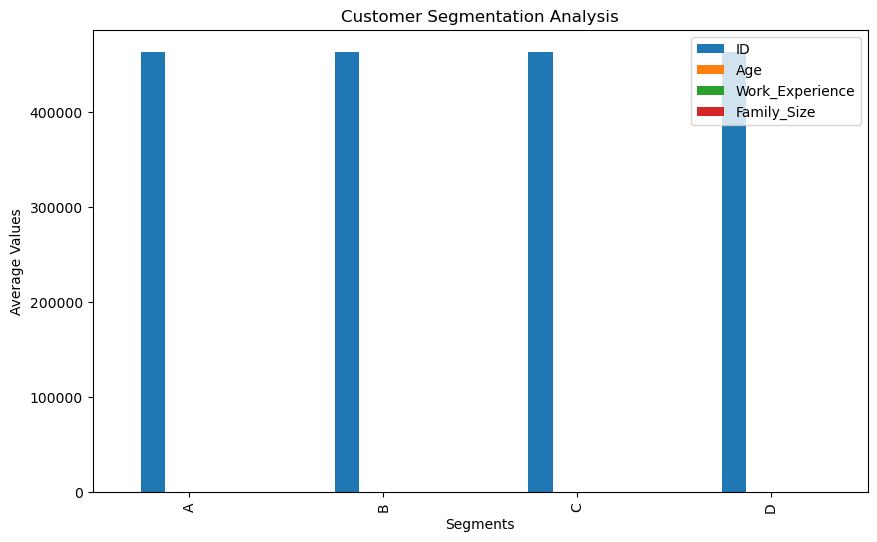

In [65]:
import matplotlib.pyplot as plt

df.groupby('Segmentation').mean(numeric_only=True).plot(kind='bar', figsize=(10,6))
plt.title("Customer Segmentation Analysis")
plt.xlabel("Segments")
plt.ylabel("Average Values")
plt.show()

In [66]:
df.groupby('Gender')[['Age','Work_Experience','Family_Size']].agg('mean')

,Age,Work_Experience,Family_Size
Gender,,,
Female,42.911531,2.814845,2.754040
Male,43.925968,2.456645,2.923251


<Axes: xlabel='Gender'>

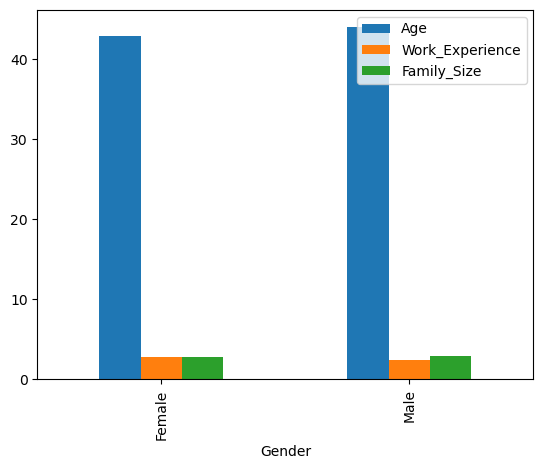

In [67]:
df.groupby('Gender')[['Age','Work_Experience','Family_Size']].agg('mean').plot(kind = 'bar')

In [68]:
# we will check for profession by gender
df.groupby(['Profession','Gender'])[['Gender']].count()

Gender
Profession    Gender        
Artist        Female    1231
              Male      1324
Doctor        Female     315
              Male       388
Engineer      Female     562
              Male       142
Entertainment Female     260
              Male       703
Executive     Female      34
              Male       571
Healthcare    Female     564
              Male       789
Homemaker     Female     203
              Male        47
Lawyer        Female     314
              Male       322
Marketing     Female     168
              Male       131

<Axes: xlabel='Profession,Gender'>

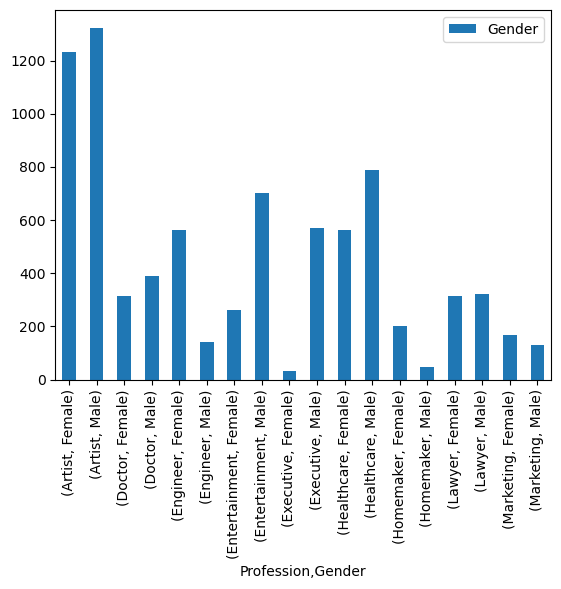

In [69]:
df.groupby(['Profession','Gender'])[['Gender']].count().plot(kind= 'bar')

In [70]:
# check the spending score by Gender
df.groupby(['Gender','Spending_Score'])[['Spending_Score']].count()

Spending_Score
Gender Spending_Score                
Female Average                    831
       High                       490
       Low                       2330
Male   Average                   1143
       High                       726
       Low                       2548

<Axes: ylabel='Gender,Spending_Score'>

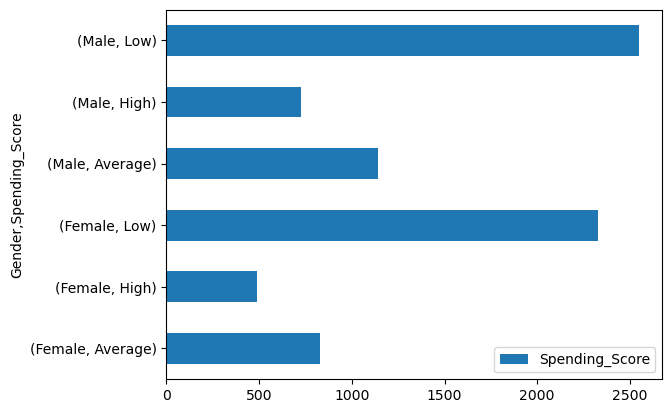

In [71]:
df.groupby(['Gender','Spending_Score'])[['Spending_Score']].count().plot(kind = 'barh')

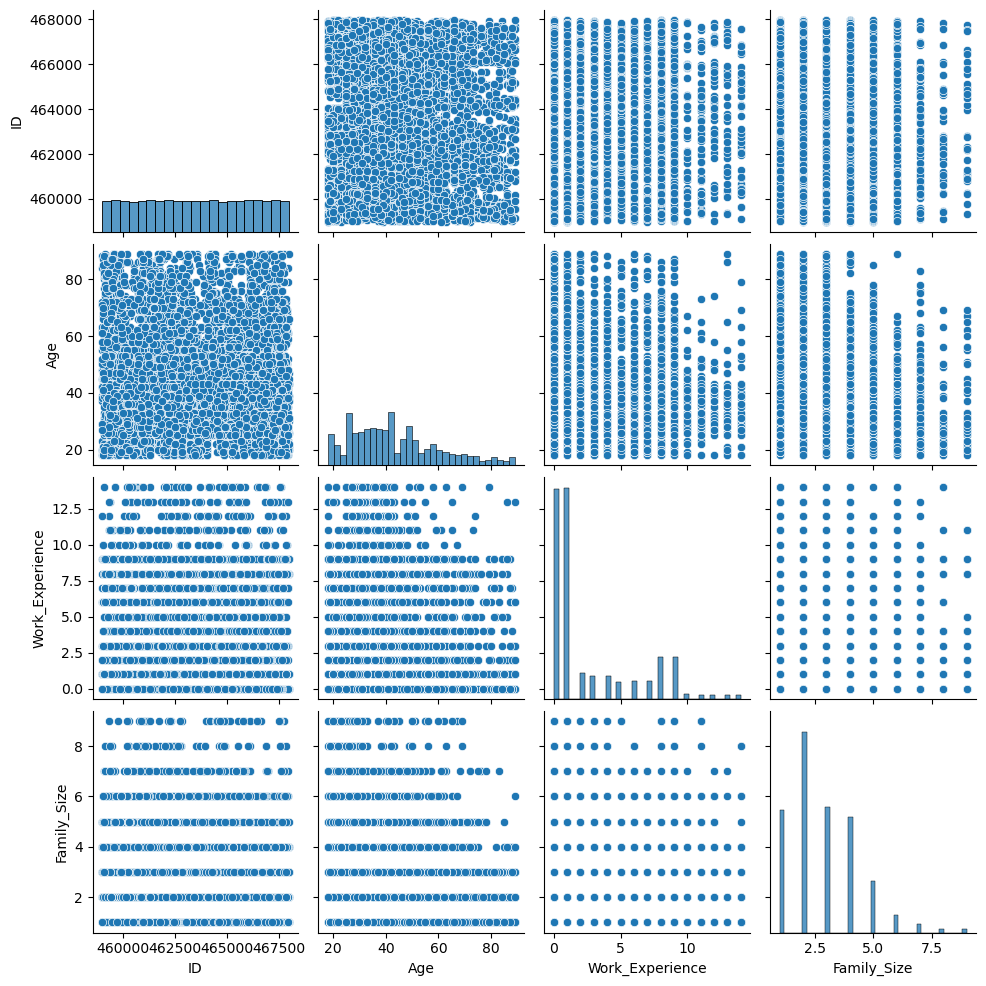

In [72]:
sns.pairplot(df)

__Checking for correlation__

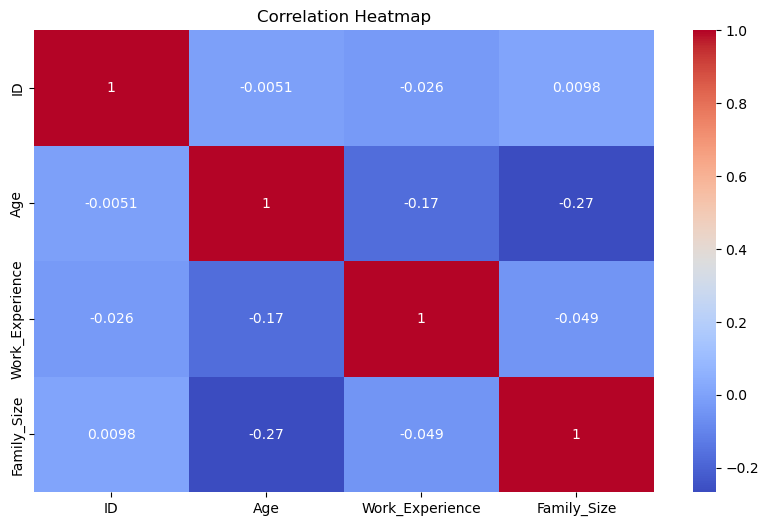

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [74]:
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,0.0,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,Artist,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


## Moving with Supervised Approach

### Data Preprocessing

One Hot Encoding

In [75]:
var = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
df_dummies = pd.get_dummies(df,columns=var)
print(df_dummies.columns.tolist())

['ID', 'Age', 'Work_Experience', 'Family_Size', 'Segmentation', 'Gender_Female', 'Gender_Male', 'Ever_Married_No', 'Ever_Married_Yes', 'Graduated_No', 'Graduated_Yes', 'Profession_Artist', 'Profession_Doctor', 'Profession_Engineer', 'Profession_Entertainment', 'Profession_Executive', 'Profession_Healthcare', 'Profession_Homemaker', 'Profession_Lawyer', 'Profession_Marketing', 'Spending_Score_Average', 'Spending_Score_High', 'Spending_Score_Low', 'Var_1_Cat_1', 'Var_1_Cat_2', 'Var_1_Cat_3', 'Var_1_Cat_4', 'Var_1_Cat_5', 'Var_1_Cat_6', 'Var_1_Cat_7']


**Using Label encoder to encode Segmentation column**

In [76]:
le = LabelEncoder()
df_dummies['Segmentation'] = le.fit_transform(df_dummies['Segmentation'])


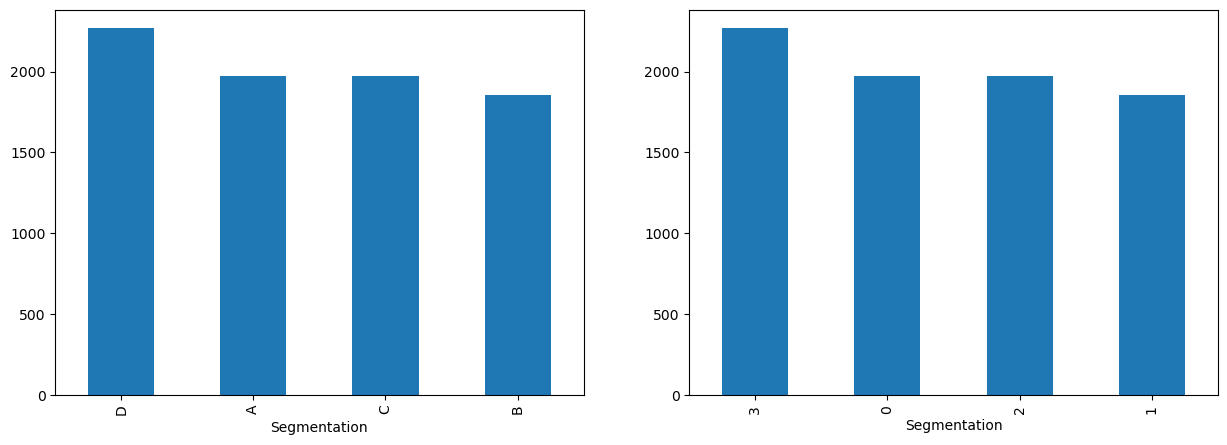

In [77]:
plt.figure(figsize = (15,5))
plt.subplot(1,2,1)
df['Segmentation'].value_counts().plot(kind = 'bar')
plt.subplot(1,2,2)
df_dummies['Segmentation'].value_counts().plot(kind = 'bar')
plt.show()

__Divide the data into train and test set__

In [78]:
X = df_dummies.drop(['Segmentation','ID'],axis = 1)
y = df_dummies['Segmentation']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.20)

**Decision Tree**

In [79]:
dct = DecisionTreeClassifier()
dct.fit(X_train,y_train)
pred= dct.predict(X_test)

In [80]:
score= accuracy_score(pred,y_test)
score

0.43308550185873607

__Random Forest__

In [81]:
rf = RandomForestClassifier(n_estimators=1000)
rf.fit(X_train,y_train)
pred1= rf.predict(X_test)

In [82]:
score= accuracy_score(pred1,y_test)
score

0.4876084262701363

In [89]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred1))
print(classification_report(y_test, pred1))

[[148 101  51  91]
 [ 91 128 104  46]
 [ 51  96 189  44]
 [ 85  37  30 322]]
              precision    recall  f1-score   support

           0       0.39      0.38      0.39       391
           1       0.35      0.35      0.35       369
           2       0.51      0.50      0.50       380
           3       0.64      0.68      0.66       474

    accuracy                           0.49      1614
   macro avg       0.47      0.48      0.47      1614
weighted avg       0.48      0.49      0.49      1614



## Model Evaluation
We evaluate the model using accuracy, confusion matrix, and classification report to understand performance.

## UnSupervised Approach

Using K Means Clustering

In [83]:
import plotly as py
import plotly.graph_objs as go
from sklearn.cluster import KMeans


1) Segmentation using Age and Family Size

In [84]:
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,0.0,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,Artist,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [85]:
X1 = df[['Age', 'Family_Size']].values

inertia = []

for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, init='k-means++', n_init=10, max_iter=300, random_state=111)
    kmeans.fit(X1)
    inertia.append(kmeans.inertia_)

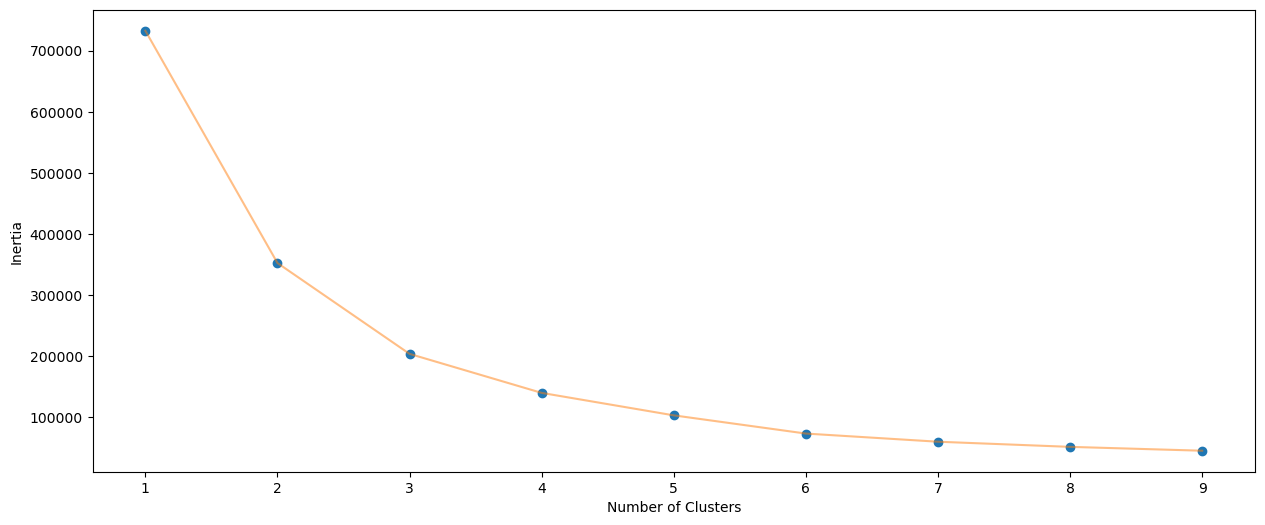

In [86]:
plt.figure(figsize=(15, 6))

x = range(1, len(inertia) + 1)

plt.plot(x, inertia, 'o')
plt.plot(x, inertia, '-', alpha=0.5)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [87]:
algorithm = (KMeans(n_clusters = 5 ,init='k-means++', n_init = 10 ,max_iter=300, 
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
algorithm.fit(X1)
labels2 = algorithm.labels_
centroids2 = algorithm.cluster_centers_

<Axes: >

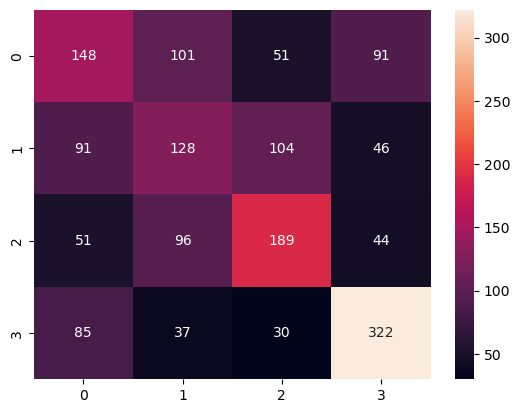

In [91]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, pred1), annot=True, fmt='d')

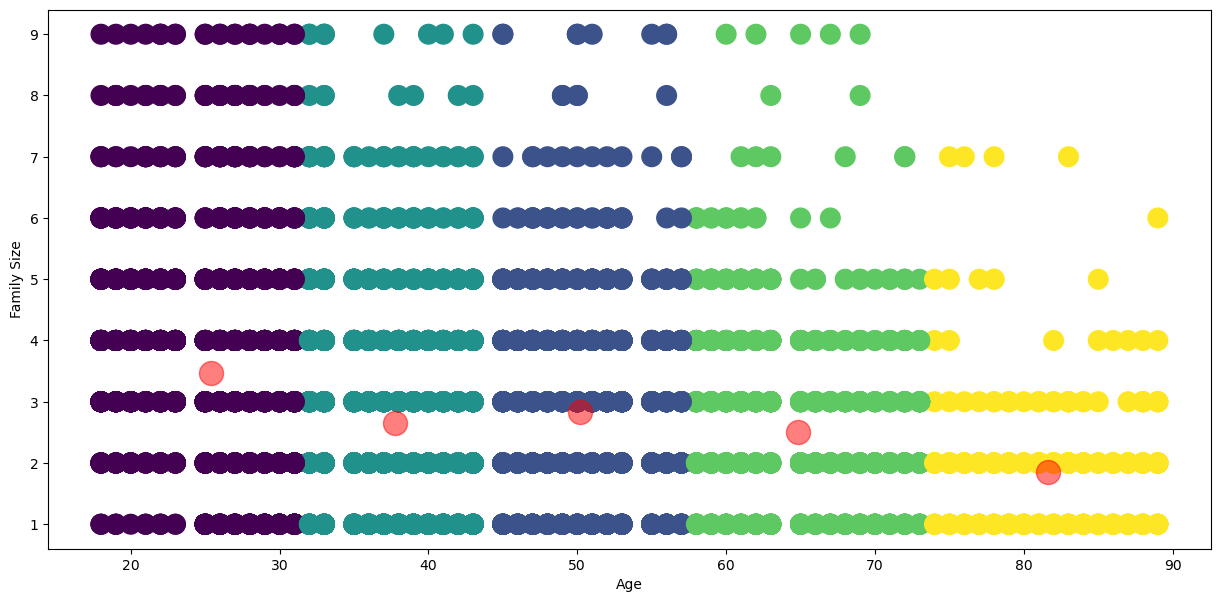

In [88]:
plt.figure(1 , figsize = (15 , 7) )


plt.scatter( x = 'Age' ,y = 'Family_Size' , data = df , c = labels2 , 
            s = 200 )
plt.scatter(x = centroids2[: , 0] , y =  centroids2[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Family Size') , plt.xlabel('Age')
plt.show()

## Insights
- Customers with higher age tend to belong to specific segments
- Family size plays a role in segmentation
- Spending score varies across different professions